# VGG16-1D-LSTM Heart Sound Classification (MFCC, 13 Features)

## GPU Setup

In [3]:
import os
import tensorflow as tf

os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    try:
        for gpu in physical_devices:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f'GPU Memory Growth Enabled for: {physical_devices}')
    except RuntimeError as e:
        print(f'GPU Error: {e}')
else:
    print('No GPU detected. Running on CPU.')


GPU Memory Growth Enabled for: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Foundation Set Up and Configuration

In [5]:
import os
import numpy as np
import librosa
import librosa.display
import scipy.signal as signal
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
import warnings
from cryptography.utils import CryptographyDeprecationWarning

warnings.filterwarnings('ignore', category=CryptographyDeprecationWarning)
np.random.seed(42)
print('Libraries imported successfully!')

# --- CONFIGURATION 
BASE_PATH = r'C:\Users\emirh\Downloads\FYP2\Pascal'
FOLDERS = ['set_a', 'set_b']
SAMPLE_RATE = 16000
DURATION = 5
SAMPLES_PER_TRACK = SAMPLE_RATE * DURATION

print(f'BASE_PATH : {BASE_PATH}')
print(f'FOLDERS   : {FOLDERS}')
print(f'SAMPLE_RATE : {SAMPLE_RATE}')
print(f'DURATION    : {DURATION}s')


Libraries imported successfully!
BASE_PATH : C:\Users\emirh\Downloads\FYP2\Pascal
FOLDERS   : ['set_a', 'set_b']
SAMPLE_RATE : 16000
DURATION    : 5s


## Data Augmentation Functions

> Identical to `DeepLearningModel_VGG19_MFCC_Test1.ipynb`. Defined here for pipeline consistency; augmentation is **not applied** to training data in this notebook.

In [7]:
def butter_bandpass(lowcut, highcut, fs, order=5):
    """Generates the filter coefficients."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = signal.butter(order, [low, high], btype='band')
    return b, a

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    """Applies the Bandpass Filter (25-400Hz)."""
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = signal.lfilter(b, a, data)
    return y

def fix_duration_segmentation(data):
    """
    Apply 5-Second Fixed Segmentation.
    - If shorter than 5s: Pad with zeros.
    - If longer than 5s: Truncate.
    """
    if len(data) > SAMPLES_PER_TRACK:
        return data[:SAMPLES_PER_TRACK]
    else:
        padding = SAMPLES_PER_TRACK - len(data)
        return np.pad(data, (0, padding), 'constant')

def z_score_normalize(data):
    """
    Applies Z-Score Normalization (Standardization).
    Result has Mean = 0, Std Dev = 1.
    """
    mean = np.mean(data)
    std = np.std(data)
    if std > 0:
        return (data - mean) / std
    else:
        return data

# AUGMENTATION FUNCTIONS
def add_noise_awgn(data):
    
    sigma = np.sqrt(np.mean(data ** 2))   # RMS of the signal
    noise = np.random.normal(0, sigma, len(data))
    return data + noise

def pitch_shift(data, sampling_rate):
   
    p = np.random.randint(1, 11)          # integer in [1, 10]
    direction = np.random.choice([-1, 1]) # up or down
    n_steps = direction * p
    return librosa.effects.pitch_shift(data, sr=sampling_rate, n_steps=n_steps)

print('Preprocessing and augmentation functions defined.')


Preprocessing and augmentation functions defined.


## Feature Extraction (MFCC — 13 features)

In [9]:
def extract_features(audio_data, sample_rate):
   
    # --- MFCC EXTRACTION: 13 coefficients ---
    mfcc = librosa.feature.mfcc(
        y=audio_data,
        sr=sample_rate,
        n_mfcc=13,
        n_fft=2048,
        hop_length=512
    )

    # --- MFCC SEQUENCE FORMAT ---
    target_time_steps = 24

    if mfcc.shape[1] < target_time_steps:
        mfcc_padded = np.pad(
            mfcc,
            ((0, 0), (0, target_time_steps - mfcc.shape[1])),
            mode='constant'
        )
    else:
        mfcc_padded = mfcc[:, :target_time_steps]

    # TRANSPOSE (.T) -> (Time_Steps=24, MFCC_Features=13)
    mfcc_sequence = mfcc_padded.T

    return mfcc_sequence

print('Feature extraction function defined.')
print('Output shape per sample: (24, 13)')


Feature extraction function defined.
Output shape per sample: (24, 13)


## Data Preparation (MFCC — Pitch Shifting + Noise Addition Augmentation)

In [11]:
from tensorflow.keras.utils import to_categorical
from collections import Counter


file_paths = []
labels = []

print('Scanning folders...')
for folder in FOLDERS:
    folder_path = os.path.join(BASE_PATH, folder)
    if not os.path.exists(folder_path):
        continue

    for filename in os.listdir(folder_path):
        filename_lower = filename.lower()

        if not filename_lower.endswith('.wav') or 'unlabel' in filename_lower:
            continue

        file_path = os.path.join(folder_path, filename)

        # Label Logic 
        label = None
        if 'noisy' in filename_lower:
            continue

        if 'normal' in filename_lower:
            label = 0
        elif 'murmur' in filename_lower:
            label = 1
        elif 'extrastole' in filename_lower or 'extrasystole' in filename_lower:
            label = 2
        elif 'artifact' in filename_lower:
            label = 3
        elif 'extrahls' in filename_lower:
            label = 4

        if label is not None:
            file_paths.append(file_path)
            labels.append(label)

# Class names 
class_names = {0: 'Normal', 1: 'Murmur', 2: 'Extrasystole', 3: 'Artifact', 4: 'ExtraHLS'}

print(f'\nTotal valid files gathered: {len(labels)}')
distribution = Counter(labels)
print('-' * 30)
print('CLASS DISTRIBUTION (Before Split):')
for label_int in sorted(distribution.keys()):
    print(f' - {class_names[label_int]}: {distribution[label_int]} files')
print('-' * 30 + '\n')

# ============================================================
# 2. STRATIFIED SPLIT: 70 / 10 / 20  
# ============================================================
X_train_val_paths, X_test_paths, y_train_val_labels, y_test_labels = train_test_split(
    file_paths, labels, test_size=0.2, stratify=labels, random_state=42
)

X_train_paths, X_val_paths, y_train_labels, y_val_labels = train_test_split(
    X_train_val_paths, y_train_val_labels, test_size=0.125, stratify=y_train_val_labels, random_state=42
)

print(f'File Counts -> Train: {len(X_train_paths)}, Val: {len(X_val_paths)}, Test: {len(X_test_paths)}')

max_original_class_count = max(distribution.values()) if len(distribution) > 0 else 0
TARGET_COUNTS = {
    0: max_original_class_count,  # Normal
    1: max_original_class_count,  # Murmur
    2: max_original_class_count,  # Extrasystole
    3: max_original_class_count,  # Artifact
    4: max_original_class_count   # ExtraHLS
}

print('\nTARGET_COUNTS for training augmentation:')
for label_int in sorted(TARGET_COUNTS.keys()):
    print(f' - {class_names[label_int]:<12}: {TARGET_COUNTS[label_int]}')


Scanning folders...

Total valid files gathered: 436
------------------------------
CLASS DISTRIBUTION (Before Split):
 - Normal: 231 files
 - Murmur: 100 files
 - Extrasystole: 46 files
 - Artifact: 40 files
 - ExtraHLS: 19 files
------------------------------

File Counts -> Train: 304, Val: 44, Test: 88

TARGET_COUNTS for training augmentation:
 - Normal      : 231
 - Murmur      : 231
 - Extrasystole: 231
 - Artifact    : 231
 - ExtraHLS    : 231


### Processing Function

In [13]:
def process_data_with_augmentation(X_paths, y_labels, augment=False):
    X_mfccs = []
    y_final = []

    # Store original preprocessed audio for augmentation
    audio_by_class = {0: [], 1: [], 2: [], 3: [], 4: []}

    print(f'   Processing {len(X_paths)} files (Augment={augment})...')

    # ====================================================
    # STEP 1: Process original files
    # ====================================================
    for i, fpath in enumerate(X_paths):
        try:
            y, sr = librosa.load(fpath, sr=SAMPLE_RATE, duration=DURATION)

            y = butter_bandpass_filter(y, 25, 400, sr)
            y = fix_duration_segmentation(y)
            y = z_score_normalize(y)

            current_label = y_labels[i]

            mfcc = extract_features(y, sr)

            X_mfccs.append(mfcc)
            y_final.append(current_label)

            audio_by_class[current_label].append((y, sr))

        except Exception as e:
            print(f'[SKIPPED ORIGINAL] {fpath} -> {e}')

    # ====================================================
    # STEP 2: Augmentation block
    #    Training split only will use augment=True.
    #    Validation and test splits remain original/unaugmented.
    #    Augmentation mode: Pitch Shifting + Noise Addition
    # ====================================================
    if augment:
        print('\n   Applying target-count augmentation: PITCH SHIFTING + NOISE ADDITION...')

        current_distribution = Counter(y_final)

        for label in sorted(TARGET_COUNTS.keys()):
            current_count = current_distribution[label]
            target_count = TARGET_COUNTS[label]
            needed = target_count - current_count

            print(
                f'   {class_names[label]:<12}: '
                f'current={current_count}, target={target_count}, need={needed}'
            )

            if needed <= 0:
                continue

            if len(audio_by_class[label]) == 0:
                print(f'   No audio available for {class_names[label]}. Skipping.')
                continue

            added = 0
            audio_index = 0

            while added < needed:
                y_original, sr = audio_by_class[label][audio_index % len(audio_by_class[label])]

                try:
                    # Both augmentations: alternate noise addition and pitch shifting
                    aug_type = added % 2
                    if aug_type == 0:
                        y_aug = add_noise_awgn(y_original)
                    else:
                        y_aug = pitch_shift(y_original, sr)

                    mfcc_aug = extract_features(y_aug, sr)

                    X_mfccs.append(mfcc_aug)
                    y_final.append(label)

                    added += 1
                    audio_index += 1

                except Exception as e:
                    print(f'   [SKIPPED AUGMENTATION] {class_names[label]} -> {e}')
                    audio_index += 1

    return np.array(X_mfccs), np.array(y_final)


In [14]:
from sklearn.utils.class_weight import compute_class_weight

# Augmentation is applied to the training split only.
# Validation and test splits are kept original/unaugmented.
print('Processing Training Data (Pitch Shifting + Noise Addition)...')
X_train_mfcc, y_train_indices = process_data_with_augmentation(
    X_train_paths, y_train_labels, augment=False
)

print('\nProcessing Validation Data (No Augmentation)...')
X_val_mfcc, y_val_indices = process_data_with_augmentation(
    X_val_paths, y_val_labels, augment=False
)

print('\nProcessing Test Data (No Augmentation)...')
X_test_mfcc, y_test_indices = process_data_with_augmentation(
    X_test_paths, y_test_labels, augment=False
)

# Distribution summary
print('\n' + '=' * 35)
print('TRAINING DATA DISTRIBUTION (Pitch Shifting + Noise Addition):')
for label_int in sorted(Counter(y_train_indices).keys()):
    print(f' - {class_names[label_int]}: {Counter(y_train_indices)[label_int]} files')
print('=' * 35 + '\n')

# Float32 conversion
X_train_mfcc = X_train_mfcc.astype('float32')
X_val_mfcc   = X_val_mfcc.astype('float32')
X_test_mfcc  = X_test_mfcc.astype('float32')

# For VGG16-1D-LSTM / Conv1D-LSTM, keep MFCC as direct sequential input.
# Feature extraction output remains: (24 time steps, 13 MFCC coefficients).
# Conv1D expects 3D input: (samples, timesteps, features) = (N, 24, 13).
# Therefore, no extra channel dimension is added here.

# One-hot encoding (5 classes — identical to CNN_MFCC notebook)
y_train = to_categorical(y_train_indices, num_classes=5)
y_val   = to_categorical(y_val_indices,   num_classes=5)
y_test  = to_categorical(y_test_indices,  num_classes=5)

y_train = y_train.astype('float32')
y_val   = y_val.astype('float32')
y_test  = y_test.astype('float32')

# Class weights are computed using the final training distribution
# after the selected training augmentation has been applied.
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_indices),
    y=y_train_indices
)
class_weights = dict(enumerate(class_weights_array))

print('--- FINAL ARRAYS READY ---')
print(f'VGG16-1D-LSTM MFCC Input Shape (Train) : {X_train_mfcc.shape}')   # (N, 24, 13)
print(f'VGG16-1D-LSTM MFCC Input Shape (Val)   : {X_val_mfcc.shape}')
print(f'VGG16-1D-LSTM MFCC Input Shape (Test)  : {X_test_mfcc.shape}')
print(f'Label Shape (Train)                    : {y_train.shape}')

print('\nClass Weights:')
for k, v in class_weights.items():
    print(f'  [{k}] {class_names[k]:<12}: {v:.4f}')


Processing Training Data (Pitch Shifting + Noise Addition)...
   Processing 304 files (Augment=False)...

Processing Validation Data (No Augmentation)...
   Processing 44 files (Augment=False)...

Processing Test Data (No Augmentation)...
   Processing 88 files (Augment=False)...

TRAINING DATA DISTRIBUTION (Pitch Shifting + Noise Addition):
 - Normal: 161 files
 - Murmur: 70 files
 - Extrasystole: 32 files
 - Artifact: 28 files
 - ExtraHLS: 13 files

--- FINAL ARRAYS READY ---
VGG16-1D-LSTM MFCC Input Shape (Train) : (304, 24, 13)
VGG16-1D-LSTM MFCC Input Shape (Val)   : (44, 24, 13)
VGG16-1D-LSTM MFCC Input Shape (Test)  : (88, 24, 13)
Label Shape (Train)                    : (304, 5)

Class Weights:
  [0] Normal      : 0.3776
  [1] Murmur      : 0.8686
  [2] Extrasystole: 1.9000
  [3] Artifact    : 2.1714
  [4] ExtraHLS    : 4.6769


## Model Training — VGG16-1D-LSTM 

In [16]:
import gc
import math
import tensorflow as tf

from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Flatten, Dense, Dropout,
    LSTM, Reshape
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence

# Clear memory
K.clear_session()
gc.collect()
print('Memory cleared.')

# Memory-safe generator 
class NumpyDataGenerator(Sequence):
    def __init__(self, X, y, batch_size=4, shuffle=True):
        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.X))
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.X) / self.batch_size)

    def __getitem__(self, index):
        batch_indices = self.indices[
            index * self.batch_size : (index + 1) * self.batch_size
        ]
        X_batch = self.X[batch_indices].astype('float32')
        y_batch = self.y[batch_indices].astype('float32')
        return X_batch, y_batch

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


BATCH_SIZE = 4

train_gen = NumpyDataGenerator(X_train_mfcc, y_train, batch_size=BATCH_SIZE, shuffle=True)
val_gen   = NumpyDataGenerator(X_val_mfcc,   y_val,   batch_size=BATCH_SIZE, shuffle=False)

print('Memory-safe generators created.')


model_vgg16_1d_lstm = Sequential(name='VGG16_1D_LSTM_MFCC_Pascal_5Class')

# Input shape: (time_steps, mfcc_features) = (24, 13)
# MaxPooling1D uses padding='same' because 24 time steps is short and
# five VGG-style pooling blocks would otherwise shrink the sequence too quickly.

# Block 1: 2 Conv1D layers + Pooling
model_vgg16_1d_lstm.add(Conv1D(
    filters=32,
    kernel_size=5,
    strides=1,
    padding='same',
    activation='relu',
    input_shape=(24, 13)
))
model_vgg16_1d_lstm.add(Conv1D(
    filters=32,
    kernel_size=5,
    strides=1,
    padding='same',
    activation='relu'
))
model_vgg16_1d_lstm.add(MaxPooling1D(pool_size=2, strides=2, padding='same'))

# Block 2: 2 Conv1D layers + Pooling
model_vgg16_1d_lstm.add(Conv1D(32, kernel_size=5, strides=1, padding='same', activation='relu'))
model_vgg16_1d_lstm.add(Conv1D(32, kernel_size=5, strides=1, padding='same', activation='relu'))
model_vgg16_1d_lstm.add(MaxPooling1D(pool_size=2, strides=2, padding='same'))

# Block 3: 3 Conv1D layers + Pooling
model_vgg16_1d_lstm.add(Conv1D(32, kernel_size=5, strides=1, padding='same', activation='relu'))
model_vgg16_1d_lstm.add(Conv1D(32, kernel_size=5, strides=1, padding='same', activation='relu'))
model_vgg16_1d_lstm.add(Conv1D(32, kernel_size=5, strides=1, padding='same', activation='relu'))
model_vgg16_1d_lstm.add(MaxPooling1D(pool_size=2, strides=2, padding='same'))

# Block 4: 3 Conv1D layers + Pooling
model_vgg16_1d_lstm.add(Conv1D(32, kernel_size=5, strides=1, padding='same', activation='relu'))
model_vgg16_1d_lstm.add(Conv1D(32, kernel_size=5, strides=1, padding='same', activation='relu'))
model_vgg16_1d_lstm.add(Conv1D(32, kernel_size=5, strides=1, padding='same', activation='relu'))
model_vgg16_1d_lstm.add(MaxPooling1D(pool_size=2, strides=2, padding='same'))

# Block 5: 3 Conv1D layers + Pooling
model_vgg16_1d_lstm.add(Conv1D(32, kernel_size=5, strides=1, padding='same', activation='relu'))
model_vgg16_1d_lstm.add(Conv1D(32, kernel_size=5, strides=1, padding='same', activation='relu'))
model_vgg16_1d_lstm.add(Conv1D(32, kernel_size=5, strides=1, padding='same', activation='relu'))
model_vgg16_1d_lstm.add(MaxPooling1D(pool_size=2, strides=2, padding='same'))

# Flatten as described in the paper, then reshape so Keras LSTM can process it.
model_vgg16_1d_lstm.add(Flatten())
model_vgg16_1d_lstm.add(Reshape((1, -1)))

# LSTM layer: number of hidden units = 100
model_vgg16_1d_lstm.add(LSTM(100))

# Three dropout layers incorporated into the architecture
model_vgg16_1d_lstm.add(Dropout(0.5))

# Fully connected layers based on the paper, adapted for 5-class output
model_vgg16_1d_lstm.add(Dense(4096, activation='relu'))
model_vgg16_1d_lstm.add(Dropout(0.5))

model_vgg16_1d_lstm.add(Dense(1000, activation='relu'))
model_vgg16_1d_lstm.add(Dropout(0.5))

# Output: 5 classes for PASCAL classification
model_vgg16_1d_lstm.add(Dense(5, activation='softmax'))

# Compile using the same optimizer setup as the CNN_MFCC notebook
model_vgg16_1d_lstm.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg16_1d_lstm.summary()

# Callbacks kept the same as the CNN_MFCC notebook
early_stopper = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

print('Training VGG16-1D-LSTM MFCC Model...')

history = model_vgg16_1d_lstm.fit(
    train_gen,
    epochs=50,
    validation_data=val_gen,
    callbacks=[early_stopper, reduce_lr],
)


Memory cleared.
Memory-safe generators created.
Model: "VGG16_1D_LSTM_MFCC_Pascal_5Class"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 24, 32)            2112      
                                                                 
 conv1d_1 (Conv1D)           (None, 24, 32)            5152      
                                                                 
 max_pooling1d (MaxPooling1D  (None, 12, 32)           0         
 )                                                               
                                                                 
 conv1d_2 (Conv1D)           (None, 12, 32)            5152      
                                                                 
 conv1d_3 (Conv1D)           (None, 12, 32)            5152      
                                                                 
 max_pooling1d_1 (MaxPooling  (None, 6, 32)         

In [17]:
import gc
from tensorflow.keras import backend as K
from tensorflow.keras.models import load_model

model_path = 'vgg16_1d_lstm_mfcc_pascal_5class_noaug.h5'

print('Current directory:', os.getcwd())

model_vgg16_1d_lstm.save(model_path)
print('Model saved successfully!')

K.clear_session()
gc.collect()
print('Memory cleared after training.')

model_vgg16_1d_lstm = load_model(model_path)
print('Model reloaded successfully!')


Current directory: C:\Users\emirh\Downloads\FYP2\Models_PASCAL\MFCC_As_Input\Hybrid_Model\Models_AftrChanges\VGG16-LSTM\Count
Model saved successfully!
Memory cleared after training.
Model reloaded successfully!


## Training Curves

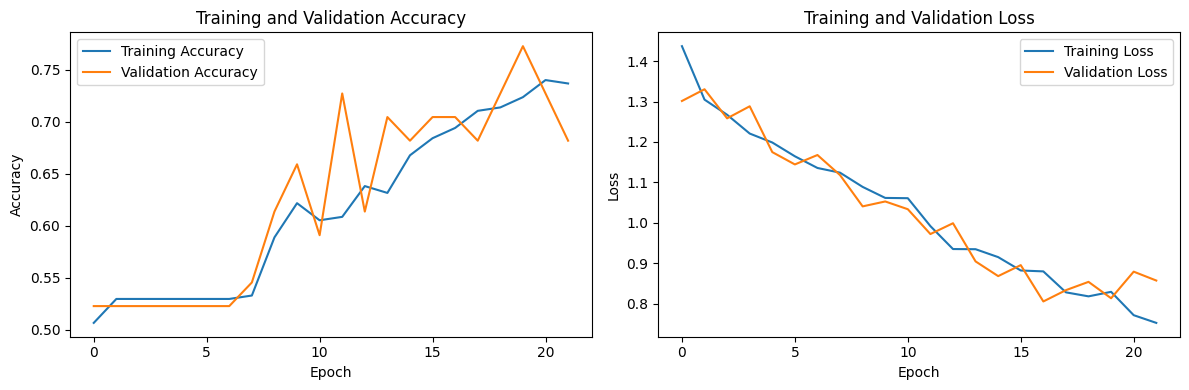

In [19]:
if 'history' in locals():
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print('No history found. Please train the model first.')


## Classification Output

> Evaluation function identical to `DeepLearningModel_VGG19_MFCC_Test1.ipynb`.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Class labels (identical to VGG19 notebook)
classes = ['Normal', 'Murmur', 'ExtraSys', 'Artifact', 'ExtraHLS']

def evaluate_and_plot_manual(model, X, y, set_name, batch_size=1):
    print(f"\n{'='*20} {set_name.upper()} RESULTS {'='*20}")

    y_true_all = []
    y_pred_all = []

    total_samples = len(X)

    for start in range(0, total_samples, batch_size):
        end = min(start + batch_size, total_samples)

        X_batch = X[start:end].astype('float32')
        y_batch = y[start:end]

        pred_batch = model.predict(X_batch, verbose=0)

        y_pred_all.extend(np.argmax(pred_batch, axis=1))
        y_true_all.extend(np.argmax(y_batch, axis=1))

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)

    acc = accuracy_score(y_true_all, y_pred_all)
    print(f'{set_name} Accuracy: {acc * 100:.2f}%')

    cm = confusion_matrix(y_true_all, y_pred_all)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=classes,
        yticklabels=classes
    )
    plt.title(f'Confusion Matrix ({set_name})')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    print(classification_report(
        y_true_all,
        y_pred_all,
        target_names=classes,
        labels=[0, 1, 2, 3, 4],
        zero_division=0
    ))



==================== TRAINING SET RESULTS ====================
Training Set Accuracy: 72.37%


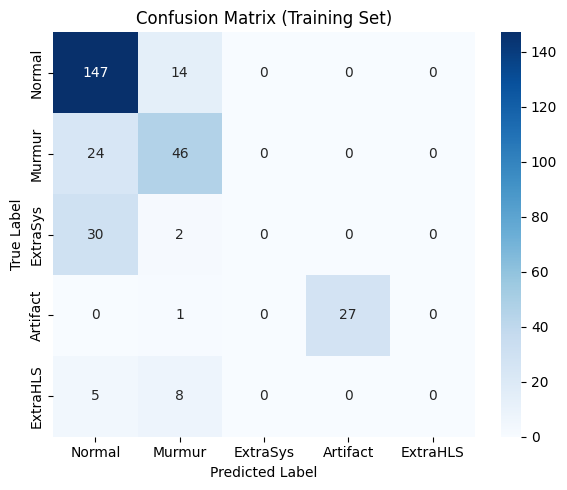

              precision    recall  f1-score   support

      Normal       0.71      0.91      0.80       161
      Murmur       0.65      0.66      0.65        70
    ExtraSys       0.00      0.00      0.00        32
    Artifact       1.00      0.96      0.98        28
    ExtraHLS       0.00      0.00      0.00        13

    accuracy                           0.72       304
   macro avg       0.47      0.51      0.49       304
weighted avg       0.62      0.72      0.66       304



In [22]:
evaluate_and_plot_manual(model_vgg16_1d_lstm, X_train_mfcc, y_train, 'Training Set', batch_size=4)


==================== VALIDATION SET RESULTS ====================
Validation Set Accuracy: 70.45%


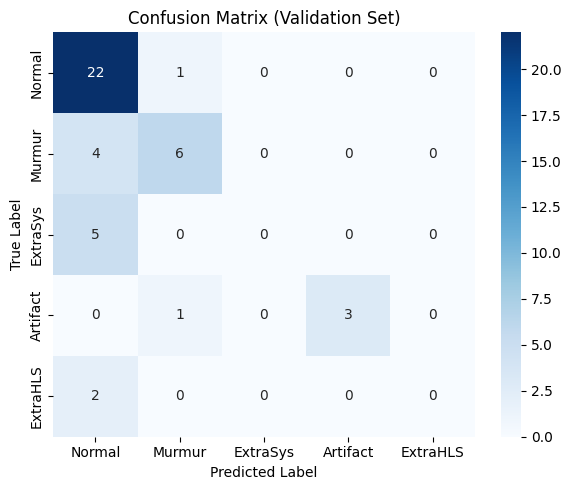

              precision    recall  f1-score   support

      Normal       0.67      0.96      0.79        23
      Murmur       0.75      0.60      0.67        10
    ExtraSys       0.00      0.00      0.00         5
    Artifact       1.00      0.75      0.86         4
    ExtraHLS       0.00      0.00      0.00         2

    accuracy                           0.70        44
   macro avg       0.48      0.46      0.46        44
weighted avg       0.61      0.70      0.64        44



In [23]:
evaluate_and_plot_manual(model_vgg16_1d_lstm, X_val_mfcc,   y_val,   'Validation Set', batch_size=4)


==================== TEST SET RESULTS ====================
Test Set Accuracy: 69.32%


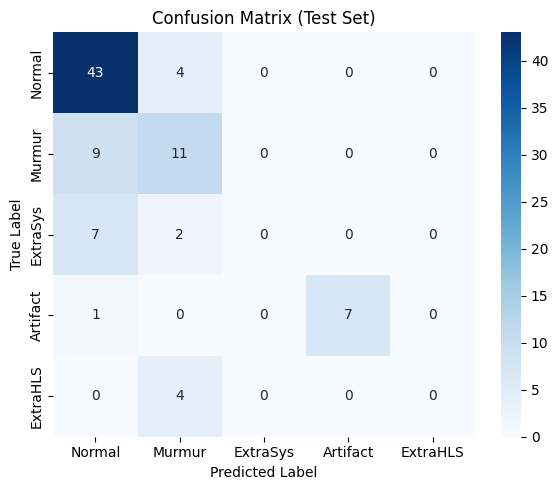

              precision    recall  f1-score   support

      Normal       0.72      0.91      0.80        47
      Murmur       0.52      0.55      0.54        20
    ExtraSys       0.00      0.00      0.00         9
    Artifact       1.00      0.88      0.93         8
    ExtraHLS       0.00      0.00      0.00         4

    accuracy                           0.69        88
   macro avg       0.45      0.47      0.45        88
weighted avg       0.59      0.69      0.64        88



In [24]:
evaluate_and_plot_manual(model_vgg16_1d_lstm, X_test_mfcc,  y_test,  'Test Set', batch_size=4)